In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [112]:
cube_location = r"/Users/jd6157/Documents/blender_projects/lewis_densities/coords_energies_8.txt" 
atoms_location = r"/Users/jd6157/Documents/blender_projects/lewis_densities/atoms.txt"
ldata = np.loadtxt(cube_location)
adata = np.loadtxt(atoms_location)

In [133]:
xs = ldata[:, 0]
ys = ldata[:, 1]
zs = ldata[:, 2]
rs = ldata[:, 0:3]

raw_energies = ldata[:, 3]

deltas = np.diff(np.sort(xs))
deltas = deltas[deltas > 0]
delta = np.min(deltas)

xs = np.arange(np.min(xs), np.max(xs), delta)
ys = np.arange(np.min(ys), np.max(ys), delta)
zs = np.arange(np.min(zs), np.max(zs), delta)

energies = np.zeros((len(xs), len(ys), len(zs)))
for i, x in enumerate(xs):
    for j, y in enumerate(ys):
        for k, z in enumerate(zs):
            eps = 0.01
            mask = (abs(ldata[:, 0] - x) < eps) & (abs(ldata[:, 1] - y) < eps) & (abs(ldata[:, 2] - z) < eps)
            if np.any(mask):
                energies[i, j, k] = ldata[mask, 3]
            else:
                energies[i, j, k] = np.nan
energies = np.nan_to_num(energies, nan=np.max(energies[~np.isnan(energies)]))
emax = 2#np.max(energies)
emin = np.min(energies)
densities = (emax - energies) / (emax - emin)
densities = np.clip(densities, 0, 1)
densities = np.nan_to_num(densities, nan=0.0)

np.max(densities), np.min(densities)

(1.0, 0.0)

In [114]:
np.percentile(raw_energies, 0.99)

-3.60729

In [136]:
np.min(densities)

0.0

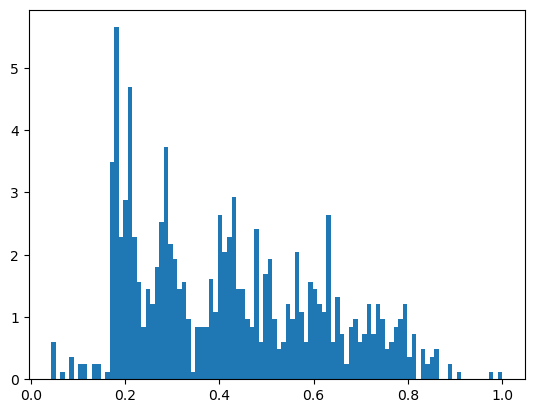

In [134]:
_ = plt.hist(densities.flatten()[densities.flatten()!=0], bins=100, density=True)
# _ = plt.hist(densities.flatten(), bins=100, density=True)

(-5.0, 10.0)

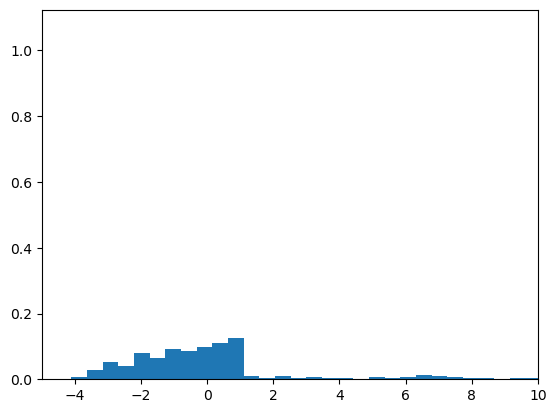

In [132]:
_ = plt.hist(energies.flatten(), bins=1000, density=True)
plt.xlim(-5, 10)

(array([ 9.52372896, 18.4330238 , 18.74024087, 15.9752873 , 10.75259722,
         7.06599246,  7.06599246,  3.68660476,  5.52990714,  3.68660476,
         1.53608532,  3.3793877 ,  1.22886825,  1.22886825,  2.15051944,
         1.53608532,  1.53608532,  2.15051944,  0.61443413,  0.92165119,
         0.30721706,  0.92165119,  1.22886825,  0.30721706,  0.61443413,
         1.53608532,  0.30721706,  0.        ,  0.        ,  0.        ,
         0.92165119,  0.61443413,  0.        ,  0.61443413,  0.10240569,
         0.92165119,  0.        ,  0.30721706,  0.        ,  0.61443413,
         0.61443413,  0.        ,  0.92165119,  0.        ,  0.        ,
         0.30721706,  0.30721706,  0.        ,  0.        ,  0.30721706,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.30721706,  0.        ,
         0.        ,  0.        ,  0.30721706,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0. 

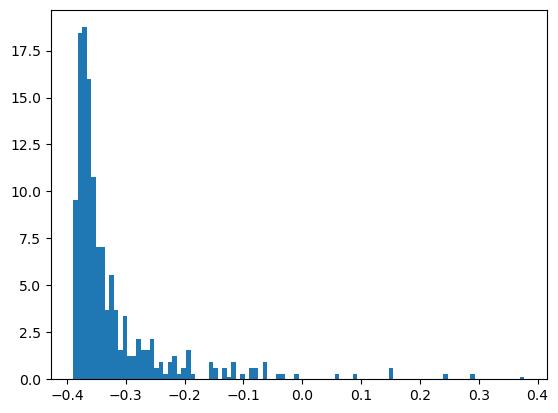

In [80]:
plt.hist(raw_energies.flatten(), bins=100, density=True)

In [111]:
xs

array([-5.     , -4.65518, -4.31036, -3.96554, -3.62072, -3.2759 ,
       -2.93108, -2.58626, -2.24144, -1.89662, -1.5518 , -1.20698,
       -0.86216, -0.51734, -0.17252,  0.1723 ,  0.51712,  0.86194,
        1.20676,  1.55158,  1.8964 ,  2.24122,  2.58604,  2.93086,
        3.27568,  3.6205 ,  3.96532,  4.31014,  4.65496,  4.99978])